In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
import requests
from scipy import stats as sps
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-08-30T23:15:14.051195+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

marimo    : 0.23.2
pandas    : 2.2.3
matplotlib: 3.10.7
teeplot   : 1.4.2
pyarrow   : 16.1.0
numpy     : 2.1.2
scipy     : 1.14.1
seaborn   : 0.13.2
requests  : 2.34.2

```

## Data

Load the per-replicate Hamming-weight **end-state** table for the
4-site mutation-rate sweep, combining three slurm jobs (all driven
by notebook `bindle/2026-05-20-founder.py`, fixing `N_SITES=4` and
`POP_SIZE=1,000,000` on CPU, engine=numpy) that together cover the
swept range at two different equilibration depths:

- **deep** sweep
  (`slurm/2026-08-26/2026-08-26-4site-mutation-sweep.sh`, OSF
  https://osf.io/96r2v): `MUTATION_RATE` from `1e-5` down to
  `3e-11` (~2 points per decade, 12 conditions planned), 25
  replicates per condition (300 planned), **`N_STEPS=150,000`**.
- **wide / high-rate** sweep
  (`slurm/2026-08-29/2026-08-29-4site-mutation-sweep.sh`, OSF
  https://osf.io/m6hzn): `MUTATION_RATE` from `1e-1` down to
  `3e-6` (~2 points per decade, 10 conditions), 200 replicates per
  condition (2000 planned), **`N_STEPS=5,000`**.
- **wide / low-rate** sweep
  (`slurm/2026-08-30/2026-08-30-4site-mutation-sweep.sh`, OSF
  https://osf.io/buz8e): `MUTATION_RATE` from `1e-6` down to
  `3e-11` (10 conditions), 200 replicates per condition (2000
  planned), **`N_STEPS=5,000`**, seeded from 201 to avoid
  replicate-uid collisions with the other two sweeps.

Both wide sweeps use a much shorter run than the deep sweep because
dynamics saturate quickly relative to `N_STEPS=150,000`; they trade
that depth for ~8x the replicate count, deliberately **duplicating**
the deep sweep's rate range rather than avoiding it, to get a
larger-N shallow estimate at the same conditions. The wide/low-rate
sweep's 10 rungs (`1e-6` .. `3e-11`) fully overlap the deep sweep's
bottom 10 rungs, so at those `mutation_rate` values this notebook
pools replicates from **two different equilibration depths**
(150,000 vs. 5,000 steps) --- the `mutation_rate x n_steps x
replicate counts` diagnostic printed below shows exactly where
that overlap falls. Rather than keeping the two depths as separate
series, a replicate that hasn't actually settled on an outcome by
its final step is instead captured directly as its own **"not
converged"** group in the outcome classification below, so a
shallow run's under-equilibration shows up as a probability rather
than being silently averaged away or requiring a second series.

The deep sweep was still in flight when this notebook was written:
not every planned condition has completed replicates yet, and
completed conditions can have far fewer than 25 replicates apiece.
Both wide sweeps are essentially complete (200 replicates at every
condition, except the high-rate sweep's `3e-4`, which has 180).
Treat the deep sweep's confidence intervals as provisional
accordingly (they should tighten, and any missing conditions fill
in, as the sweep continues and its OSF file is refreshed).

All three OSF files back this notebook as **full per-step
trajectory tables** (one row per `(replicate_uid, Step, hw)`)
rather than pre-filtered end-state exports, so loading any of them
wholesale with `pandas` risks exhausting memory. Instead, each
file's final-step filter (`Step == max(Step)`, computed per file
since `N_STEPS` differs between the deep and wide sweeps) is
pushed down through `pyarrow.dataset` before materializing to
`pandas` and concatenating, since every completed replicate is
recorded densely for every step (no checkpointing).

All three OSF files are downloaded with `requests` and cached at
`/tmp/<slug>` so re-runs hit the local copies.

In [ ]:
# CLI args. Defaults pull the three 4-site mutation-sweep hw
# parquets that back this notebook: deep (OSF https://osf.io/96r2v),
# wide/high-rate (OSF https://osf.io/m6hzn), and wide/low-rate (OSF
# https://osf.io/buz8e) --- see the Data section above.
_args = mo.cli_args()
_default_slugs = {
    "deep": "96r2v",
    "wide_high": "m6hzn",
    "wide_low": "buz8e",
}
OSF_SOURCES = {}
for _name, _default_slug in _default_slugs.items():
    _slug = str(_args.get(f"osf-slug-{_name}") or _default_slug)
    _url = str(
        _args.get(f"osf-url-{_name}")
        or f"https://osf.io/{_slug}/download",
    )
    OSF_SOURCES[_name] = (_slug, _url)
    print(f"args: OSF_SLUG_{_name}={_slug} OSF_URL_{_name}={_url}")

args: OSF_SLUG_deep=96r2v OSF_URL_deep=https://osf.io/96r2v/download
args: OSF_SLUG_wide_high=m6hzn OSF_URL_wide_high=https://osf.io/m6hzn/download
args: OSF_SLUG_wide_low=buz8e OSF_URL_wide_low=https://osf.io/buz8e/download


In [ ]:
def _download(slug, url):
    cache_path = pathlib.Path("/tmp") / slug
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=300)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return cache_path

cache_paths = {
    _name: _download(_slug, _url)
    for _name, (_slug, _url) in OSF_SOURCES.items()
}

downloading https://osf.io/96r2v/download -> /tmp/96r2v
size: 249699504 bytes
downloading https://osf.io/m6hzn/download -> /tmp/m6hzn
size: 257102274 bytes
downloading https://osf.io/buz8e/download -> /tmp/buz8e
size: 160239028 bytes


In [ ]:
def _load_final_step(cache_path):
    # Each parquet is the full per-step trajectory table for its
    # sweep, so avoid pd.read_parquet(cache_path) --- loading every
    # step of every replicate into pandas is enough on its own to
    # exhaust memory on a typical runner. Every completed replicate
    # is recorded densely for every step (no checkpointing), so
    # pushing a Step == max(Step) filter down through pyarrow
    # before converting to pandas recovers exactly the end-state
    # rows at a fraction of the memory cost. max(Step) is computed
    # per file since N_STEPS differs between the deep and wide
    # sweeps.
    _dataset = ds.dataset(cache_path, format="parquet")
    _max_step = pc.max(
        _dataset.to_table(columns=["Step"])["Step"],
    ).as_py()
    return _dataset.to_table(
        filter=(pc.field("Step") == _max_step),
        columns=[
            "hw",
            "n_cases",
            "replicate_uid",
            "mutation_rate",
            "n_sites",
            "n_steps",
        ],
    ).to_pandas()

hw_df = pd.concat(
    [_load_final_step(_p) for _p in cache_paths.values()],
    ignore_index=True,
)
print(f"loaded hw end-state dataframe: {hw_df.shape}")
print(
    "mutation_rate x n_steps x replicate counts:\n"
    + str(
        hw_df.groupby(["mutation_rate", "n_steps"])[
            "replicate_uid"
        ].nunique(),
    ),
)

loaded hw end-state dataframe: (20400, 6)
mutation_rate x n_steps x replicate counts:
mutation_rate  n_steps
3.000000e-11   5000       200
               150000      11
1.000000e-10   5000       200
               150000      10
3.000000e-10   5000       200
                         ... 
1.000000e-03   5000       200
3.000000e-03   5000       200
1.000000e-02   5000       200
3.000000e-02   5000       200
1.000000e-01   5000       200
Name: replicate_uid, Length: 29, dtype: int64


## Fixation Outcome per Replicate

For each replicate, identify the **dominant Hamming-weight class**
at its final simulation step by case count (`n_cases`) --- the
Hamming-weight bin that has "fixed" as the most-populous strain
cluster at end-state, following the coarse strain identifier used
in the founder-convergence analyses. Replicates from all three
sweeps are pooled together at each `mutation_rate` (see the Data
section above): a replicate that hasn't actually settled on an
outcome by its final step --- disproportionately likely among the
wide sweeps' shallower `N_STEPS=5,000` runs --- falls into its own
**"not converged"** group below rather than being forced into a
class it hasn't really reached, or requiring a separate depth-based
series.

With `N_SITES=4` there are five Hamming-weight classes drawn from
the sixteen possible genomes, grouped into four outcomes:

- **founder strain (0000/1111)**: Hamming weights `0` and `4`,
  i.e. the all-zero founder/wildtype genome and its bitwise
  complement (`hw in {0, 4}`, 2 of the 16 genomes).
- **HW 1/3 complements**: Hamming weights `1` and `3`, the one-
  and three-mutation classes that are bitwise complements of one
  another (`hw in {1, 3}`, 8 of the 16 genomes).
- **HW 2**: Hamming weight `2`, the remaining two-mutation class
  (`hw == 2`, 6 of the 16 genomes). Unlike the other two groups
  this one isn't a complement pair --- e.g. `1100` and `0011` are
  each other's complements, but both land in `hw == 2` --- it's
  just every genome not already claimed by founder or HW 1/3.
- **not converged**: no single Hamming-weight class holds at least
  90% of the replicate's final-step case count (`dom_frac < 0.9`).
  `dom_frac` is sharply bimodal across this combined dataset ---
  either roughly `0.35`-`0.5` (still split across several classes)
  or `>= 0.99` (essentially fixed) --- with almost no replicates in
  between, so 90% sits cleanly in that gap rather than being an
  arbitrary cutoff.

We classify each replicate's end-state into one of these four
categories, then ask how the **probability of each outcome**
depends on the swept `mutation_rate`. Splitting HW 1/3 from HW 2
(rather than lumping all of `hw in {1, 2, 3}` together, as the
2-/3-site companion notebooks do) matters here because the two
groups carry different genome counts (8 vs. 6 of 16) and thus
different chance baselines.

In [ ]:
_n_sites = int(hw_df["n_sites"].iloc[0])
# A replicate hasn't reached a definite outcome once no single
# Hamming-weight class holds at least 90% of its final-step case
# count --- see the "not converged" rationale above.
_CONVERGED_THRESHOLD = 0.9

# hw_df already holds one row per (replicate_uid, hw) at each
# replicate's final step (filtered upstream in load_data), so the
# dominant Hamming-weight class per replicate is just the hw with
# the largest n_cases, and dom_frac is that hw's share of the
# replicate's total case count.
_grouped = hw_df.groupby("replicate_uid")["n_cases"]
_dom_frac = _grouped.max() / _grouped.sum()
_dom_idx = _grouped.idxmax()
outcome_df = hw_df.loc[
    _dom_idx,
    ["replicate_uid", "mutation_rate", "hw"],
].copy()
outcome_df["dom_frac"] = outcome_df["replicate_uid"].map(_dom_frac)

# Founder strain (0000/1111) == extreme Hamming weights {0, N_SITES};
# HW 1/3 == the complement pair; HW 2 == everything else (not itself
# a complement pair --- see delimit_outcome above).
def _classify(_row):
    if _row["dom_frac"] < _CONVERGED_THRESHOLD:
        return "not converged"
    if _row["hw"] in (0, _n_sites):
        return "founder (0000/1111)"
    if _row["hw"] == _n_sites // 2:
        return "HW 2"
    return "HW 1/3 (complements)"

outcome_df["group"] = outcome_df.apply(_classify, axis=1)
print(f"outcome frame: {outcome_df.shape}")
print(
    "dominant hw class counts:\n"
    + str(outcome_df["hw"].value_counts().sort_index()),
)
print(
    "group counts:\n" + str(outcome_df["group"].value_counts()),
)

outcome frame: (4080, 5)
dominant hw class counts:
hw
0     976
1     487
2    1973
3     347
4     297
Name: count, dtype: int64
group counts:
group
not converged           2538
HW 2                     912
founder (0000/1111)      604
HW 1/3 (complements)      26
Name: count, dtype: int64


## Exact (Clopper-Pearson) 95% Confidence Intervals

Each replicate's outcome label is one of four mutually exclusive,
collectively exhaustive categories, so for each `mutation_rate` the
"outcome X vs. not" indicator is a Bernoulli trial per replicate
and the per-condition fraction is a **binomial proportion**.
Replicates are pooled across all three sweeps at each
`mutation_rate` regardless of `n_steps` (see the Data and Fixation
Outcome sections above for how the differing equilibration depths
are instead surfaced via the "not converged" group). We summarize
each of the four group proportions independently with the **exact
Clopper-Pearson interval** via `scipy.stats.binomtest(k,
n).proportion_ci(method="exact")` --- an exact estimator CI
inverted from the binomial CDF, **not** a bootstrap.
Per-condition replicate counts in this combined dataset are uneven
and can be as low as single digits for the deep sweep's sparser
conditions (vs. its planned 25), up to 200 for the wide sweeps, so
expect some intervals to be wide.

In [ ]:
_groups = [
    "founder (0000/1111)",
    "HW 1/3 (complements)",
    "HW 2",
    "not converged",
]
_rows = []
for _mr, _sub in outcome_df.groupby("mutation_rate"):
    _n = len(_sub)
    _counts = _sub["group"].value_counts()
    for _group in _groups:
        _k = int(_counts.get(_group, 0))
        _ci = sps.binomtest(_k, _n).proportion_ci(
            confidence_level=0.95,
            method="exact",
        )
        _rows.append(
            {
                "mutation_rate": float(_mr),
                "group": _group,
                "n_group": _k,
                "n_total": _n,
                "p": _k / _n,
                "ci_low": float(_ci.low),
                "ci_high": float(_ci.high),
            },
        )

summary_df = (
    pd.DataFrame(_rows)
    .sort_values(["group", "mutation_rate"])
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))

 mutation_rate                group  n_group  n_total        p   ci_low  ci_high
  3.000000e-11 HW 1/3 (complements)        0      211 0.000000 0.000000 0.017331
  1.000000e-10 HW 1/3 (complements)        1      210 0.004762 0.000121 0.026245
  3.000000e-10 HW 1/3 (complements)        3      213 0.014085 0.002914 0.040607
  1.000000e-09 HW 1/3 (complements)       10      210 0.047619 0.023068 0.085828
  3.000000e-09 HW 1/3 (complements)       12      212 0.056604 0.029587 0.096787
  1.000000e-08 HW 1/3 (complements)        0      204 0.000000 0.000000 0.017920
  3.000000e-08 HW 1/3 (complements)        0      200 0.000000 0.000000 0.018275
  1.000000e-07 HW 1/3 (complements)        0      204 0.000000 0.000000 0.017920
  3.000000e-07 HW 1/3 (complements)        0      220 0.000000 0.000000 0.016628
  1.000000e-06 HW 1/3 (complements)        0      216 0.000000 0.000000 0.016933
  3.000000e-06 HW 1/3 (complements)        0      200 0.000000 0.000000 0.018275
  1.000000e-05 HW 1/3 (compl

## Fixation Probability vs. Mutation Rate

`seaborn` lineplot of the per-condition outcome probability against
`mutation_rate` on a **log x-axis**, one line per outcome group
(replicates pooled across all three sweeps at each `mutation_rate`
--- see the Data section above). The shaded **band shows the exact
(Clopper-Pearson) 95% confidence interval** computed above
(seaborn's own bootstrap CI is disabled via `errorbar=None`; the
band is drawn from the exact estimator). The three fixation groups
each get a color-matched dashed **horizontal chance-expectation
rule**, at the genome-count fraction of the 16 possible 4-site
genomes they cover: **12.5%** for founder (0000/1111, 2 genomes),
**50%** for HW 1/3 complements (8 genomes), and **37.5%** for HW 2
(6 genomes) --- all under a uniform-over-genomes null. "not
converged" has no genome-identity analog (it's about whether any
class dominates at all, not which one), so it gets no chance line.
Gaps along the x-axis reflect mutation-rate conditions with no
completed replicates yet in this sweep snapshot.

teeplots/2026-08-26-4site-mutation-sweep/a=founder-vs-hw13-vs-hw2-vs-unconverged-fixation-prob+hue=group+marker=o+viz=lineplot+x=mutation-rate+y=p+ext=.pdf
teeplots/2026-08-26-4site-mutation-sweep/a=founder-vs-hw13-vs-hw2-vs-unconverged-fixation-prob+hue=group+marker=o+viz=lineplot+x=mutation-rate+y=p+ext=.png


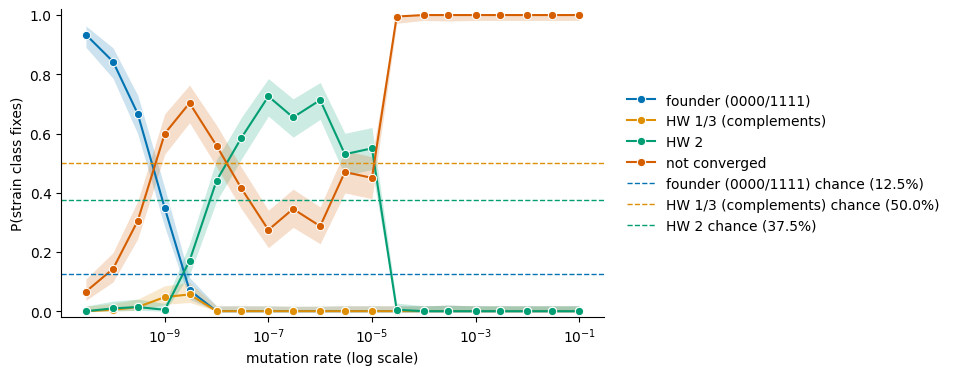

In [ ]:
_groups = [
    "founder (0000/1111)",
    "HW 1/3 (complements)",
    "HW 2",
    "not converged",
]
_palette = dict(
    zip(_groups, sns.color_palette("colorblind", n_colors=len(_groups))),
)
# Genome-count fraction of the 16 possible 4-site genomes each
# fixation group covers, under a uniform-over-genomes null: founder
# {0000, 1111} (2), HW 1/3 complements (2 * C(4,1) = 8), HW 2
# (C(4,2) = 6). "not converged" has no genome-identity analog, so
# it's intentionally absent here and gets no chance line below.
_chance = {
    "founder (0000/1111)": 2 / 16,
    "HW 1/3 (complements)": 8 / 16,
    "HW 2": 6 / 16,
}

with tp.teed(
    sns.lineplot,
    data=summary_df,
    x="mutation_rate",
    y="p",
    hue="group",
    hue_order=_groups,
    palette=_palette,
    marker="o",
    errorbar=None,
    teeplot_outattrs={
        "a": "founder-vs-hw13-vs-hw2-vs-unconverged-fixation-prob",
    },
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _ax:
    # Exact-CI band per group (fill_between, not bootstrap).
    for _group in _groups:
        _sub = summary_df[summary_df["group"] == _group].sort_values(
            "mutation_rate",
        )
        _ax.fill_between(
            _sub["mutation_rate"],
            _sub["ci_low"],
            _sub["ci_high"],
            color=_palette[_group],
            alpha=0.2,
            linewidth=0,
        )
    # Color-matched chance-expectation rule per group with a defined
    # genome-count baseline (skips "not converged").
    for _group in _groups:
        if _group not in _chance:
            continue
        _ax.axhline(
            _chance[_group],
            color=_palette[_group],
            linestyle="--",
            linewidth=1.0,
            label=f"{_group} chance ({_chance[_group]:.1%})",
        )
    _ax.set_xscale("log")
    _ax.set_ylim(-0.02, 1.02)
    _ax.set_xlabel("mutation rate (log scale)")
    _ax.set_ylabel("P(strain class fixes)")
    _ax.legend(
        title=None,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
    sns.despine(ax=_ax)
    _ax.figure.set_size_inches(7, 4)

## Probability & 95% CI Table

Per-`mutation_rate` outcome probability with the exact
Clopper-Pearson 95% confidence interval, for all four outcome
groups. `n_group` / `n_total` are the binomial counts behind each
estimate.

In [ ]:
_table_df = (
    summary_df.assign(
        p=summary_df["p"].round(4),
        ci_low=summary_df["ci_low"].round(4),
        ci_high=summary_df["ci_high"].round(4),
        ci_95=summary_df.apply(
            lambda _r: f"[{_r['ci_low']:.3f}, {_r['ci_high']:.3f}]",
            axis=1,
        ),
    )[
        [
            "group",
            "mutation_rate",
            "n_group",
            "n_total",
            "p",
            "ci_low",
            "ci_high",
            "ci_95",
        ]
    ]
    .sort_values(["group", "mutation_rate"])
    .reset_index(drop=True)
)

print(_table_df.to_string(index=False))
mo.ui.table(_table_df, selection=None)

               group  mutation_rate  n_group  n_total      p  ci_low  ci_high          ci_95
HW 1/3 (complements)   3.000000e-11        0      211 0.0000  0.0000   0.0173 [0.000, 0.017]
HW 1/3 (complements)   1.000000e-10        1      210 0.0048  0.0001   0.0262 [0.000, 0.026]
HW 1/3 (complements)   3.000000e-10        3      213 0.0141  0.0029   0.0406 [0.003, 0.041]
HW 1/3 (complements)   1.000000e-09       10      210 0.0476  0.0231   0.0858 [0.023, 0.086]
HW 1/3 (complements)   3.000000e-09       12      212 0.0566  0.0296   0.0968 [0.030, 0.097]
HW 1/3 (complements)   1.000000e-08        0      204 0.0000  0.0000   0.0179 [0.000, 0.018]
HW 1/3 (complements)   3.000000e-08        0      200 0.0000  0.0000   0.0183 [0.000, 0.018]
HW 1/3 (complements)   1.000000e-07        0      204 0.0000  0.0000   0.0179 [0.000, 0.018]
HW 1/3 (complements)   3.000000e-07        0      220 0.0000  0.0000   0.0166 [0.000, 0.017]
HW 1/3 (complements)   1.000000e-06        0      216 0.0000  0.0000  

,group,mutation_rate,n_group,n_total,p,ci_low,ci_high,ci_95
0,HW 1/3 (complements),3.000000e-11,0,211,0.0000,0.0000,0.0173,"[0.000, 0.017]"
1,HW 1/3 (complements),1.000000e-10,1,210,0.0048,0.0001,0.0262,"[0.000, 0.026]"
2,HW 1/3 (complements),3.000000e-10,3,213,0.0141,0.0029,0.0406,"[0.003, 0.041]"
3,HW 1/3 (complements),1.000000e-09,10,210,0.0476,0.0231,0.0858,"[0.023, 0.086]"
4,HW 1/3 (complements),3.000000e-09,12,212,0.0566,0.0296,0.0968,"[0.030, 0.097]"
...,...,...,...,...,...,...,...,...
75,not converged,1.000000e-03,200,200,1.0000,0.9817,1.0000,"[0.982, 1.000]"
76,not converged,3.000000e-03,200,200,1.0000,0.9817,1.0000,"[0.982, 1.000]"
77,not converged,1.000000e-02,200,200,1.0000,0.9817,1.0000,"[0.982, 1.000]"
78,not converged,3.000000e-02,200,200,1.0000,0.9817,1.0000,"[0.982, 1.000]"
